# LLM-prompts Topic Classification

In [ ]:
!pip install -q datasets transformers scikit-learn torch

In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

## Load Split dataset

In [ ]:
# from datasets import load_dataset, concatenate_datasets

# # Load your original dataset
# dataset = load_dataset("maryamdar/topic_classification_dataset_gen")

# # Load the second dataset
# dataset2 = load_dataset("maryamdar/topic-classification-dataset-real")
# # Load the second dataset
# dataset3 = load_dataset("maryamdar/topic-classification-dataset-real-2")
# dataset2_train = dataset2["train"].filter(
#     lambda x: x["label"] != "Not Related"
# )
# dataset3_train = dataset3["train"].filter(
#     lambda x: x["label"] != "Not Related"
# )
# dataset2_train = dataset2_train.select_columns([
#     "text",
#     "label",
#     "parent_label"
# ])
# dataset3_train = dataset3_train.select_columns([
#     "text",
#     "label",
#     "parent_label"
# ])

# dataset["train"] = dataset["train"].filter(lambda x: x["use_for_train"] is True)
# for col in dataset["train"].column_names:
#     if col not in dataset2_train.column_names:
#         dataset2_train = dataset2_train.add_column(
#             col,
#             [None] * len(dataset2_train)
#         )
# for col in dataset["train"].column_names:
#     if col not in dataset3_train.column_names:
#         dataset3_train = dataset3_train.add_column(
#             col,
#             [None] * len(dataset3_train)
#         )
# # Make sure column order is identical
# dataset2_train = dataset2_train.select_columns(
#     dataset["train"].column_names
# )
# # Make sure column order is identical
# dataset3_train = dataset3_train.select_columns(
#     dataset["train"].column_names
# )

# # Merge them
# dataset["train"] = concatenate_datasets([
#     dataset["train"],
#     dataset2_train
# ])
# dataset["train"] = concatenate_datasets([
#     dataset["train"],
#     dataset3_train
# ])
# print(dataset["train"])
# print("Total rows:", len(dataset["train"]))

README.md:   0%|          | 0.00/597 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.24MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/22192 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/474 [00:00<?, ?B/s]

...

Filter:   0%|          | 0/1889 [00:00<?, ? examples/s]

Filter:   0%|          | 0/22192 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/5563 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1880 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train'],
    num_rows: 27826
})
Total rows: 27826


In [ ]:
# Load dataset
dataset = load_dataset("maryamdar/topic_classification_dataset_gen")

README.md:   0%|          | 0.00/597 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.18MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/29618 [00:00<?, ? examples/s]

### Filter Training Data

In [ ]:
dataset["train"] = dataset["train"].filter(lambda x: x["use_for_train"] is True)

Filter:   0%|          | 0/29618 [00:00<?, ? examples/s]

### Further Filter Training Data (Remove Specific Generator Model)

In [ ]:
dataset["train"] = dataset["train"].filter(
    lambda x: x["generator_model"] != "MiMo V2.5 Free"
)

Filter:   0%|          | 0/27809 [00:00<?, ? examples/s]

### Define Label Order

In [ ]:
LABEL_ORDER = [
    "Desktop & Mobile & Web Development",
    "Cybersecurity",
    "AI / Machine Learning / Data Science",
    "Infrastructure (DevOps, Cloud, Databases, Networking)",
    "Clinical Diagnosis, Treatment & Surgery",
    "Medication & Pharmacology",
    "Mental Health",
    "Healthcare Organizations, System, Hospitals",
    "Nutrition",
    "Payments & Personal Budgeting",
    "Investment, Markets & Cryptocurrency",
    "Corporate",
    "Physics, Mathematics",
    "Chemistry",
    "Biology",
    "Team Sports",
    "Individual Sports",
    "Fitness",
    "Civil, Structural & Architecture",
    "Mechanical & Electrical Engineering",
    "Family & Relationships",
    "Personal",
    "Travel",
    "Marketing & Sales",
    "Entrepreneurship & Startups",
    "Management & Strategy & Human Resources",
    "Criminal Law",
    "Family Law",
    "Corporate Law",
    "Civil Law" ,
    "Game",
    "Film",
    "Music",
    "Literature",
    "Painting",
]

### Define Label Hierarchy (Parent-Child Mapping)

In [ ]:
# Parent-to-Child Mapping Hierarchy
HIERARCHY = {
    "Programming / Technology": [
        "Desktop & Mobile & Web Development",
        "Cybersecurity",
        "AI / Machine Learning / Data Science",
        "Infrastructure (DevOps, Cloud, Databases, Networking)"
    ],
    "Medical": [
        "Clinical Diagnosis, Treatment & Surgery",
        "Medication & Pharmacology",
        "Mental Health",
        "Healthcare Organizations, System, Hospitals",
        "Nutrition"
    ],
    "Finance": [
        "Payments & Personal Budgeting",
        "Investment, Markets & Cryptocurrency",
        "Corporate"
    ],
    "Science": [
        "Physics, Mathematics",
        "Chemistry",
        "Biology"
    ],
    "Sports": [
        "Team Sports",
        "Individual Sports",
        "Fitness"
    ],
    "Engineering": [
        "Civil, Structural & Architecture",
        "Mechanical & Electrical Engineering",
    ],
    "Personal": [
        "Family & Relationships",
        "Personal",
        "Travel"
    ],
    "Business": [
        "Marketing & Sales",
        "Entrepreneurship & Startups",
        "Management & Strategy & Human Resources"
    ],
     "Law": [
        "Criminal Law",
        "Family Law",
        "Corporate Law",
        "Civil Law"
    ],
     "Art": [
        "Game",
        "Film",
        "Music",
        "Literature",
        "Painting"
    ],


}

# Invert mapping to find a parent from any child label
CHILD_TO_PARENT = {}
for parent, children in HIERARCHY.items():
    for child in children:
        CHILD_TO_PARENT[child] = parent

### Initial Data Overview and Cleaning

In [ ]:
import pandas as pd

df = dataset["train"].to_pandas()

print("--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Missing (Null) Values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

# Duplicate Text Entries
duplicate_texts = df.duplicated(subset=['text']).sum()
print("--- Duplicates ---")
print(f"Number of exact duplicate text rows: {duplicate_texts}")
print(f"Percentage of duplicates: {(duplicate_texts / len(df)) * 100:.2f}%")
print("\n" + "="*40 + "\n")

# Class Distribution (Rows per Label)
print("--- All Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Dataset Info ---
Total Rows: 19108
Columns: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train']

--- Missing Values ---
text                    0
old_label           11815
old_parent_label    11815
generator_model         0
source                  0
generation_group     2983
label                   0
parent_label            0
use_for_train           0
dtype: int64


--- Duplicates ---
Number of exact duplicate text rows: 0
Percentage of duplicates: 0.00%


--- All Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1315    6.881934
                                        Cybersecurity   1013    5.301444
                                        Mental Health   1003    5.249110
          Healthcare Organizations, System, Hospitals    943    4.935106
                 AI / Machine Learning / Data Science    837    

### Drop Missing Values and Duplicates

In [ ]:
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'], keep='first')

### Display Label Examples

In [ ]:
print(f"Total Unique Labels: {len(LABEL_ORDER)}")
print(f"All Label Names: {LABEL_ORDER}\n")

print("=" * 50)
print("--- 3 EXAMPLES PER LABEL ---")
print("=" * 50)

for label_name in LABEL_ORDER:
    print(f"\n🏷️  LABEL: {label_name}")
    print("-" * 40)

    samples = df[df["label"] == label_name]["text"].head(3)

    if len(samples) == 0:
        print("(No examples)")
        continue

    for i, example in enumerate(samples, 1):
        clean_text = example.replace("\n", " ")
        if len(clean_text) > 150:
            print(f"[{i}] {clean_text[:150]}...")
        else:
            print(f"[{i}] {clean_text}")

Total Unique Labels: 35
All Label Names: ['Desktop & Mobile & Web Development', 'Cybersecurity', 'AI / Machine Learning / Data Science', 'Infrastructure (DevOps, Cloud, Databases, Networking)', 'Clinical Diagnosis, Treatment & Surgery', 'Medication & Pharmacology', 'Mental Health', 'Healthcare Organizations, System, Hospitals', 'Nutrition', 'Payments & Personal Budgeting', 'Investment, Markets & Cryptocurrency', 'Corporate', 'Physics, Mathematics', 'Chemistry', 'Biology', 'Team Sports', 'Individual Sports', 'Fitness', 'Civil, Structural & Architecture', 'Mechanical & Electrical Engineering', 'Family & Relationships', 'Personal', 'Travel', 'Marketing & Sales', 'Entrepreneurship & Startups', 'Management & Strategy & Human Resources', 'Criminal Law', 'Family Law', 'Corporate Law', 'Civil Law', 'Game', 'Film', 'Music', 'Literature', 'Painting']

--- 3 EXAMPLES PER LABEL ---

🏷️  LABEL: Desktop & Mobile & Web Development
----------------------------------------
[1] react query cache invalid

## Label encoding

In [ ]:
from datasets import Dataset

# Fixed mapping
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

# Encode labels
df["label_id"] = df["label"].map(label_to_id)

# Safety check
if df["label_id"].isna().any():
    missing = df[df["label_id"].isna()]["label"].unique()
    raise ValueError(f"Unknown labels found: {missing}")

print("Label Map:")
print(id_to_label)

# Convert back to HF Dataset
clean_dataset = Dataset.from_pandas(df, preserve_index=False)

Label Map:
{0: 'Desktop & Mobile & Web Development', 1: 'Cybersecurity', 2: 'AI / Machine Learning / Data Science', 3: 'Infrastructure (DevOps, Cloud, Databases, Networking)', 4: 'Clinical Diagnosis, Treatment & Surgery', 5: 'Medication & Pharmacology', 6: 'Mental Health', 7: 'Healthcare Organizations, System, Hospitals', 8: 'Nutrition', 9: 'Payments & Personal Budgeting', 10: 'Investment, Markets & Cryptocurrency', 11: 'Corporate', 12: 'Physics, Mathematics', 13: 'Chemistry', 14: 'Biology', 15: 'Team Sports', 16: 'Individual Sports', 17: 'Fitness', 18: 'Civil, Structural & Architecture', 19: 'Mechanical & Electrical Engineering', 20: 'Family & Relationships', 21: 'Personal', 22: 'Travel', 23: 'Marketing & Sales', 24: 'Entrepreneurship & Startups', 25: 'Management & Strategy & Human Resources', 26: 'Criminal Law', 27: 'Family Law', 28: 'Corporate Law', 29: 'Civil Law', 30: 'Game', 31: 'Film', 32: 'Music', 33: 'Literature', 34: 'Painting'}


### Encode Labels and Convert to Hugging Face Dataset

## Train/Test Split

In [ ]:
from datasets import ClassLabel

# Get the number of unique classes
num_classes = len(df['label_id'].unique())

# Cast 'label_id' to ClassLabel type
clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# Now the stratified split will work smoothly
split_dataset = clean_dataset.train_test_split(
    test_size=0.2,
    stratify_by_column="label_id",
    seed=42
)

train_ds = split_dataset["train"]
test_ds = split_dataset["test"]
print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

Casting the dataset:   0%|          | 0/19108 [00:00<?, ? examples/s]

Train samples: 15286 | Test samples: 3822


### Perform Stratified Train/Test Split

In [ ]:
train_ds[0]

{'text': 'My company is offering an ESPP with a 15% discount and a same-day sale option. Is there any reason not to max this out and sell immediately for free money?',
 'old_label': 'Investment, Markets & Cryptocurrency',
 'old_parent_label': 'Finance',
 'generator_model': 'deepseek-v4',
 'source': 'generated',
 'generation_group': None,
 'label': 'Investment, Markets & Cryptocurrency',
 'parent_label': 'Finance',
 'use_for_train': True,
 'label_id': 10}

### Inspect a Sample from the Training Dataset

In [ ]:
import pandas as pd
df = train_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Train Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Train Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1052    6.882114
                                        Cybersecurity    810    5.298966
                                        Mental Health    802    5.246631
          Healthcare Organizations, System, Hospitals    754    4.932618
                 AI / Machine Learning / Data Science    670    4.383096
              Clinical Diagnosis, Treatment & Surgery    633    4.141044
Infrastructure (DevOps, Cloud, Databases, Networking)    607    3.970954
                 Investment, Markets & Cryptocurrency    556    3.637315
                            Medication & Pharmacology    539    3.526102
                                            Nutrition    472    3.087793
                                                Music    463    3.028915
                                              Fitness    437    2.858825
                  Mechan

In [ ]:
import pandas as pd
df = test_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Test Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Test Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development    263    6.881214
                                        Cybersecurity    203    5.311355
                                        Mental Health    201    5.259027
          Healthcare Organizations, System, Hospitals    189    4.945055
                 AI / Machine Learning / Data Science    167    4.369440
              Clinical Diagnosis, Treatment & Surgery    158    4.133961
Infrastructure (DevOps, Cloud, Databases, Networking)    152    3.976975
                 Investment, Markets & Cryptocurrency    139    3.636839
                            Medication & Pharmacology    135    3.532182
                                            Nutrition    118    3.087389
                                                Music    116    3.035060
                                              Fitness    109    2.851910
                  Mechani

## Preprocessing & Embeddings

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "BAAI/bge-small-en-v1.5"
# model_name = 	"BAAI/bge-large-en"


### Load Tokenizer and Model

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  133MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

### Define Mean Pooling Function

In [ ]:
# mean pooling helper
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

### Define Embedding Extraction Function

In [ ]:
# Batch processing function
def extract_embeddings(batch):
    encoded_input = tokenizer(
        batch["text"],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        model_output = model(**encoded_input)

    sentence_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
    sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)

    return {"embedding": sentence_embeddings.cpu().numpy()}

### Extract Embeddings for Train and Test Sets

In [ ]:
# embedding extraction
train_embedded = train_ds.map(extract_embeddings, batched=True, batch_size=32)
test_embedded = test_ds.map(extract_embeddings, batched=True, batch_size=32)

Map:   0%|          | 0/15286 [00:00<?, ? examples/s]

Map:   0%|          | 0/3822 [00:00<?, ? examples/s]

### Convert Embeddings and Labels to NumPy Arrays

In [ ]:
# Convert features and target labels into numpy arrays
X_train = np.array(train_embedded["embedding"])
y_train = np.array(train_embedded["label_id"])

X_test = np.array(test_embedded["embedding"])
y_test = np.array(test_embedded["label_id"])

### Train SGD Classifier (Iterative Training)

In [ ]:
y_train[0]

### Check Shape of Training Embeddings

In [ ]:
X_train[0].shape

### Setup Device and Model

# Single Classifier

## Train Classifier

Epoch 01/30 | Loss: 0.5352 | Accuracy: 0.9264
Epoch 02/30 | Loss: 0.5469 | Accuracy: 0.9312
Epoch 03/30 | Loss: 0.5526 | Accuracy: 0.9331
Epoch 04/30 | Loss: 0.5491 | Accuracy: 0.9355
Epoch 05/30 | Loss: 0.5298 | Accuracy: 0.9304
Epoch 06/30 | Loss: 0.5406 | Accuracy: 0.9327
Epoch 07/30 | Loss: 0.5397 | Accuracy: 0.9344
Epoch 08/30 | Loss: 0.5404 | Accuracy: 0.9366
Epoch 09/30 | Loss: 0.5334 | Accuracy: 0.9352
Epoch 10/30 | Loss: 0.5436 | Accuracy: 0.9343
Epoch 11/30 | Loss: 0.5330 | Accuracy: 0.9361
Epoch 12/30 | Loss: 0.5382 | Accuracy: 0.9368
Epoch 13/30 | Loss: 0.5360 | Accuracy: 0.9358
Epoch 14/30 | Loss: 0.5396 | Accuracy: 0.9346
Epoch 15/30 | Loss: 0.5376 | Accuracy: 0.9360
Epoch 16/30 | Loss: 0.5361 | Accuracy: 0.9367
Epoch 17/30 | Loss: 0.5401 | Accuracy: 0.9356
Epoch 18/30 | Loss: 0.5373 | Accuracy: 0.9353
Epoch 19/30 | Loss: 0.5394 | Accuracy: 0.9358
Epoch 20/30 | Loss: 0.5363 | Accuracy: 0.9362
Epoch 21/30 | Loss: 0.5346 | Accuracy: 0.9360
Epoch 22/30 | Loss: 0.5365 | Accur

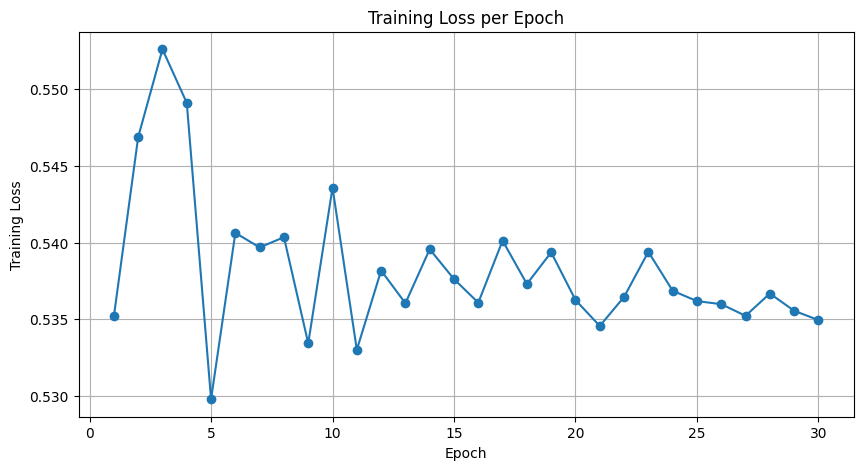

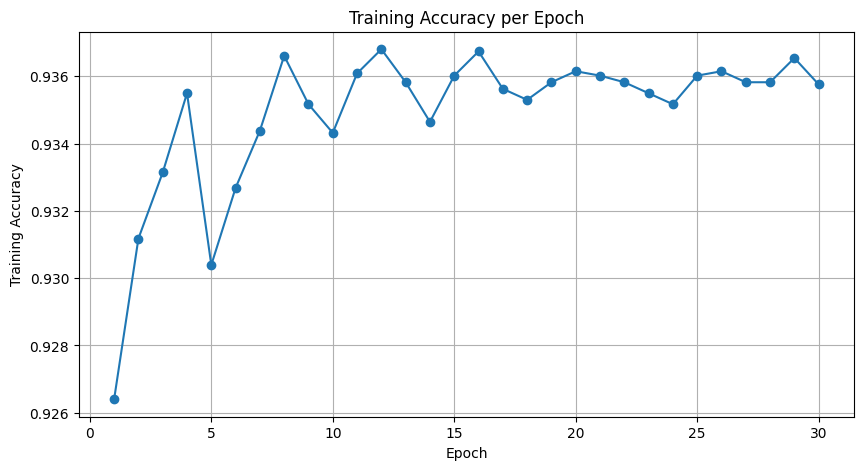

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

# ============================================================
# MODEL
# ============================================================

classifier = SGDClassifier(
    loss="log_loss",       # Logistic Regression
    max_iter=1,            # We manually control epochs
    learning_rate="optimal",
    random_state=42
)

# ============================================================
# TRAINING
# ============================================================

EPOCHS = 30

train_losses = []
train_accuracies = []

classes = np.unique(y_train)

for epoch in range(EPOCHS):

    # Shuffle data every epoch
    indices = np.random.permutation(len(X_train))

    X_epoch = X_train[indices]
    y_epoch = y_train.iloc[indices] if hasattr(y_train, "iloc") else y_train[indices]

    # One epoch
    classifier.partial_fit(
        X_epoch,
        y_epoch,
        classes=classes
    )

    # --------------------------------------------------------
    # Predictions
    # --------------------------------------------------------

    y_train_pred = classifier.predict(X_train)
    y_train_prob = classifier.predict_proba(X_train)

    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    loss = log_loss(
        y_train,
        y_train_prob,
        labels=classes
    )

    accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    train_losses.append(loss)
    train_accuracies.append(accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Loss: {loss:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )

# ============================================================
# PLOTS
# ============================================================

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss per Epoch")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracies, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy per Epoch")
plt.grid(True)
plt.show()

### Train Logistic Regression Classifier (One-shot Training)

In [ ]:
classifier = LogisticRegression(max_iter=1000, C=1.0)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

### Save Trained Classifier and Label Mappings

In [ ]:
import joblib
import json

# Save trained classifier
joblib.dump(classifier, "classifier.joblib")

# Save label mappings
id_to_label = {i: label for label, i in label_to_id.items()}
with open("label_mappings.json", "w") as f:
    json.dump({"id_to_label": {str(k): v for k, v in id_to_label.items()}}, f)

### Define Prediction Function

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

In [ ]:
def predict_model(classifier, X_test):
    return classifier.predict(X_test)

### Word Extraction Utilities

## overlap misclassification

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


# ============================================================
# WORDS TO IGNORE
# ============================================================

CUSTOM_COMMON_WORDS = {
    # Instructions / requests
    "using", "use", "used", "uses",
    "make", "making", "made","said",
    "create", "creating", "created",
    "generate", "generating", "generated",
    "write", "writing", "written",
    "explain", "explaining", "explained",
    "describe", "describing", "described",
    "provide", "providing", "provided",
    "show", "showing", "shown",
    "give", "giving", "given","look","looks",
    "tell", "telling","says","does",

    # Modal / generic request words
    "should", "must", "would", "could",
    "can", "may", "might",
    "need", "needs", "needed",
    "want", "wants", "wanted",
    "please","tried",

    # Generic prompt words
    "question", "questions",
    "answer", "answers",
    "prompt", "prompts",
    "response", "responses",
    "text", "texts",
    "example", "examples",
    "information",
    "problem", "problems",
    "solution", "solutions",

    # Generic verbs
    "get", "gets", "getting",
    "take", "takes", "taking",
    "find", "finds", "finding",
    "know", "knows",
    "consider", "considering",
    "include", "including", "included",
    "discuss",
    "help", "helps", "helping",

    # Generic filler
    "like", "also", "just",
    "really", "often",
    "usually", "generally",
    "different", "specific",
    "following","actually",
    "based", "according",
    "way", "ways","trying","doing",
    "thing", "things",
    "type", "types",
    "kind", "kinds",

    # Generic quantities
    "one", "two", "three",
    "first", "second", "third",
    "many", "much",
}


STOP_WORDS = set(ENGLISH_STOP_WORDS) | CUSTOM_COMMON_WORDS


def extract_words(text):
    """
    Extract meaningful English words from text.
    """

    words = re.findall(
        r"\b[a-zA-Z]{3,}\b",
        str(text).lower()
    )

    return [
        word
        for word in words
        if word not in STOP_WORDS
    ]

### Top Words Extraction and Printing Functions

In [ ]:
def get_top_words_per_label(
    texts,
    labels,
    label_order,
    top_n=10,
):
    """
    Extract top N most frequent words for each label.
    """

    label_counters = {
        label: Counter()
        for label in label_order
    }

    for text, label_id in zip(texts, labels):

        label = label_order[int(label_id)]

        label_counters[label].update(
            extract_words(text)
        )

    top_words = {
        label: counter.most_common(top_n)
        for label, counter in label_counters.items()
    }

    return top_words


def print_top_words(top_words):
    """
    Print top words and their frequencies.
    """

    print("\n" + "=" * 70)
    print("TOP WORDS PER LABEL")
    print("=" * 70)

    for label, words in top_words.items():

        print(f"\n{label}")
        print("-" * len(label))

        for word, frequency in words:
            print(f"{word:<25} {frequency}")

### Misclassification Analysis Function

In [ ]:
def analyze_all_misclassifications(
    texts,
    y_test,
    y_pred,
    label_order,
    top_words,
):
    """
    Return ALL misclassified samples.

    For each misclassification, check whether the sample
    contains top words from:
        - the true label
        - the predicted label

    If no words are found, write "None".
    """

    # ----------------------------------------------------
    # Map ID -> label name
    # ----------------------------------------------------

    id_to_label = {
        i: label
        for i, label in enumerate(label_order)
    }

    # ----------------------------------------------------
    # Convert top words to sets for fast lookup
    # ----------------------------------------------------

    top_word_sets = {
        label: {
            word
            for word, _ in words
        }
        for label, words in top_words.items()
    }

    results = []

    # ----------------------------------------------------
    # Analyze every sample
    # ----------------------------------------------------

    for text, true_value, pred_value in zip(
        texts,
        y_test,
        y_pred,
    ):

        # ------------------------------------------------
        # Convert TRUE label to label name
        # ------------------------------------------------

        if isinstance(true_value, (int, np.integer)):
            true_label = id_to_label[int(true_value)]
        else:
            true_label = str(true_value)

        # ------------------------------------------------
        # Convert PREDICTED label to label name
        # ------------------------------------------------

        if isinstance(pred_value, (int, np.integer)):
            predicted_label = id_to_label[int(pred_value)]
        else:
            predicted_label = str(pred_value)

        # ------------------------------------------------
        # Keep ONLY misclassifications
        # ------------------------------------------------

        if true_label == predicted_label:
            continue

        # ------------------------------------------------
        # Words in this sample
        # ------------------------------------------------

        sample_words = set(
            extract_words(text)
        )

        # ------------------------------------------------
        # Find TRUE label top words
        # ------------------------------------------------

        true_words_found = (
            sample_words
            & top_word_sets.get(true_label, set())
        )

        # ------------------------------------------------
        # Find PREDICTED label top words
        # ------------------------------------------------

        predicted_words_found = (
            sample_words
            & top_word_sets.get(predicted_label, set())
        )

        # ------------------------------------------------
        # Save ALL misclassifications
        # ------------------------------------------------

        results.append({
            "true_label": true_label,
            "predicted_label": predicted_label,

            "true_label_words": (
                ", ".join(sorted(true_words_found))
                if true_words_found
                else "None"
            ),

            "predicted_label_words": (
                ", ".join(sorted(predicted_words_found))
                if predicted_words_found
                else "None"
            ),

            "num_true_label_words":
                len(true_words_found),

            "num_predicted_label_words":
                len(predicted_words_found),

            "text": text,
        })

    # ----------------------------------------------------
    # Create DataFrame
    # ----------------------------------------------------

    result_df = pd.DataFrame(results)

    pd.set_option(
        "display.max_colwidth",
        None
    )
    result_df.to_csv(
    "misclassified_analysis.csv",
    index=False,
    encoding="utf-8-sig"
  )

    return result_df

### Overlap Matrix Creation and Plotting Functions

In [ ]:
def create_overlap_matrix(
    overlap_misclassifications,
    label_order,
):
    """
    Rows    = true child labels
    Columns = predicted child labels

    Each cell = number of overlap-based misclassifications.
    """

    matrix = pd.DataFrame(
        0,
        index=label_order,
        columns=label_order,
        dtype=int,
    )

    for _, row in overlap_misclassifications.iterrows():

        matrix.loc[
            row["true_label"],
            row["predicted_label"]
        ] += 1

    return matrix


def plot_overlap_matrix(
    matrix,
    title,
    xlabel,
    ylabel,
    figsize=(12, 9),
):
    plt.figure(figsize=figsize)

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={
            "label": "Misclassifications with word overlap"
        },
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)

    plt.tight_layout()
    plt.show()

### Parent-Level Analysis Functions

In [ ]:
def add_parent_labels(
    overlap_misclassifications,
    hierarchy,
):
    """
    Add true_parent and predicted_parent columns.
    """

    child_to_parent = {
        child: parent
        for parent, children in hierarchy.items()
        for child in children
    }

    result = overlap_misclassifications.copy()

    result["true_parent"] = (
        result["true_label"]
        .map(child_to_parent)
    )

    result["predicted_parent"] = (
        result["predicted_label"]
        .map(child_to_parent)
    )

    result["same_parent"] = (
        result["true_parent"]
        ==
        result["predicted_parent"]
    )

    return result


def create_parent_overlap_matrix(
    overlap_misclassifications,
    hierarchy,
):
    """
    Parent × parent overlap matrix.
    """

    parent_labels = list(hierarchy.keys())

    matrix = pd.DataFrame(
        0,
        index=parent_labels,
        columns=parent_labels,
        dtype=int,
    )

    for _, row in overlap_misclassifications.iterrows():

        matrix.loc[
            row["true_parent"],
            row["predicted_parent"]
        ] += 1

    return matrix


def create_within_parent_summary(
    overlap_misclassifications,
):
    """
    Shows child-label confusion inside the same parent.
    """

    within_parent = overlap_misclassifications[
        overlap_misclassifications["same_parent"]
    ]

    if within_parent.empty:
        return pd.DataFrame()

    return (
        within_parent
        .groupby(
            [
                "true_parent",
                "true_label",
                "predicted_label",
            ]
        )
        .size()
        .reset_index(
            name="overlap_misclassifications"
        )
        .sort_values(
            "overlap_misclassifications",
            ascending=False,
        )
    )


def create_parent_summary(
    overlap_misclassifications,
    hierarchy,
):
    """
    Shows how much overlap-based confusion each parent has
    internally versus with other parents.
    """

    rows = []

    for parent in hierarchy.keys():

        parent_rows = overlap_misclassifications[
            overlap_misclassifications["true_parent"]
            == parent
        ]

        total = len(parent_rows)

        within = parent_rows[
            parent_rows["same_parent"]
        ].shape[0]

        cross = total - within

        rows.append({
            "parent": parent,
            "within_parent_overlap": within,
            "cross_parent_overlap": cross,
            "total_overlap": total,
        })

    return pd.DataFrame(rows)

### Main Word Overlap Analysis Pipeline

In [ ]:
def run_word_overlap_analysis(
    X_train,
    y_train,
    X_test,
    y_test,
    y_pred,
    label_order,
    hierarchy,
    top_n=10,
):
    """
    Run the complete word-overlap analysis.
    """

    # ========================================================
    # 1. TOP WORDS
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 1 — EXTRACTING TOP WORDS")
    print("=" * 80)

    # top_words = get_top_words_per_label(
    #     texts=X_train,
    #     labels=y_train,
    #     label_order=label_order,
    #     top_n=top_n,
    # )

    # print_top_words(top_words)

    # Combine train + test

    X_all = list(X_train) + list(X_test)
    y_all = list(y_train) + list(y_test)

    # Get top words from ALL data
    top_words = get_top_words_per_label(
        texts=X_all,
        labels=y_all,
        label_order=label_order,
        top_n=top_n,
    )

    print_top_words(top_words)


    # ========================================================
    # 2. FIND OVERLAP MISCLASSIFICATIONS
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 2 — FINDING OVERLAP MISCLASSIFICATIONS")
    print("=" * 80)

    overlap_misclassifications = (
        analyze_all_misclassifications(
            texts=X_test,
            y_test=y_test,
            y_pred=y_pred,
            label_order=label_order,
            top_words=top_words,
        )
    )


    # Add parent information
    overlap_misclassifications = add_parent_labels(
        overlap_misclassifications,
        hierarchy,
    )


    # ========================================================
    # 3. PRINT OVERLAP SAMPLES
    # ========================================================

    total_misclassified = sum(
        int(true) != int(pred)
        for true, pred in zip(y_test, y_pred)
    )

    total_overlap = len(
        overlap_misclassifications
    )

    print(
        f"\nTotal misclassified samples: "
        f"{total_misclassified}"
    )

    print(
        f"Misclassified samples with word overlap: "
        f"{total_overlap}"
    )

    if total_misclassified > 0:

        print(
            f"Percentage of misclassifications "
            f"associated with overlap: "
            f"{total_overlap / total_misclassified:.2%}"
        )


    if overlap_misclassifications.empty:

        print(
            "\nNo misclassifications were found where "
            "both labels' top words appeared in the sample."
        )

    else:

        print("\nOverlap-based misclassifications:")

        display(
            overlap_misclassifications[
                [
                    "true_parent",
                    "predicted_parent",
                    "true_label",
                    "predicted_label",
                    "true_label_words",
                    "predicted_label_words",
                    "text",
                ]
            ]
        )


    # ========================================================
    # 4. CHILD-LEVEL MATRIX
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 3 — CHILD-LEVEL OVERLAP MATRIX")
    print("=" * 80)

    child_overlap_matrix = create_overlap_matrix(
        overlap_misclassifications,
        label_order,
    )

    display(child_overlap_matrix)

    plot_overlap_matrix(
        matrix=child_overlap_matrix,
        title=(
            "Child-Level Misclassifications "
            "Associated with Word Overlap"
        ),
        xlabel="Predicted Label",
        ylabel="True Label",
        figsize=(13, 11),
    )


    # ========================================================
    # 5. PARENT-LEVEL MATRIX
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 4 — PARENT-LEVEL OVERLAP MATRIX")
    print("=" * 80)

    parent_overlap_matrix = create_parent_overlap_matrix(
        overlap_misclassifications,
        hierarchy,
    )

    display(parent_overlap_matrix)

    plot_overlap_matrix(
        matrix=parent_overlap_matrix,
        title=(
            "Parent-Level Misclassifications "
            "Associated with Word Overlap"
        ),
        xlabel="Predicted Parent",
        ylabel="True Parent",
        figsize=(12, 10),
    )


    # ========================================================
    # 6. WITHIN-PARENT CONFUSIONS
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 5 — WITHIN-PARENT CHILD CONFUSIONS")
    print("=" * 80)

    within_parent_summary = (
        create_within_parent_summary(
            overlap_misclassifications
        )
    )

    if within_parent_summary.empty:
        print("No within-parent overlap misclassifications.")

    else:
        display(within_parent_summary)


    # ========================================================
    # 7. PARENT SUMMARY
    # ========================================================

    print("\n" + "=" * 80)
    print("STEP 6 — PARENT SUMMARY")
    print("=" * 80)

    parent_summary = create_parent_summary(
        overlap_misclassifications,
        hierarchy,
    )

    display(parent_summary)


    # ========================================================
    # 8. OVERALL WITHIN VS CROSS PARENT
    # ========================================================

    if total_overlap > 0:

        within_parent_count = (
            overlap_misclassifications[
                "same_parent"
            ].sum()
        )

        cross_parent_count = (
            total_overlap
            - within_parent_count
        )

        print("\n" + "=" * 80)
        print("STEP 7 — WITHIN VS CROSS PARENT")
        print("=" * 80)

        print(
            f"Within-parent overlap: "
            f"{within_parent_count} "
            f"({within_parent_count / total_overlap:.2%})"
        )

        print(
            f"Cross-parent overlap: "
            f"{cross_parent_count} "
            f"({cross_parent_count / total_overlap:.2%})"
        )


    # ========================================================
    # RETURN EVERYTHING
    # ========================================================

    return {
        "top_words": top_words,
        "overlap_misclassifications":
            overlap_misclassifications,
        "child_overlap_matrix":
            child_overlap_matrix,
        "parent_overlap_matrix":
            parent_overlap_matrix,
        "within_parent_summary":
            within_parent_summary,
        "parent_summary":
            parent_summary,
    }

### Extract Raw Text and Label IDs

In [ ]:
# ============================================================
# CONVERT HF DATASETS TO X / Y
# ============================================================

X_train_raw = train_ds["text"]
y_train_raw = train_ds["label_id"]

X_test_raw = test_ds["text"]
y_test_raw = test_ds["label_id"]

print(f"X_train: {len(X_train)}")
print(f"y_train: {len(y_train)}")
print(f"X_test:  {len(X_test)}")
print(f"y_test:  {len(y_test)}")

### Function to Save Misclassified Samples

## Evaluation Plots and Report

In [ ]:
import json
import pandas as pd


def save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
):
    # Make a copy so we don't modify the original
    df_test = df_test.copy()

    # Add predictions
    df_test["predicted_label"] = y_pred

    # Keep only misclassified samples
    misclassified = df_test[
        df_test["label"] != df_test["predicted_label"]
    ].copy()

    # Save ALL columns
    misclassified.to_json(
        output_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(f"Misclassified samples: {len(misclassified)}")
    print(f"Saved to: {output_path}")

    return misclassified

### Function to Display Classification Report

In [ ]:
def show_classification_report(
    y_test,
    y_pred,
    label_order,
    save_report=False,
):
    label_ids = list(range(len(label_order)))

    report = classification_report(
        y_test,
        y_pred,
        labels=label_ids,
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=label_ids,
            target_names=label_order,
            zero_division=0,
        )
    )

    summary = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro F1-Score",
            "Weighted F1-Score",
        ],
        "Test": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred, average="weighted"),
        ],
    })

    summary["Test"] = summary["Test"].map("{:.2%}".format)

    display(summary)

    return report

### Function to Plot Child Confusion Matrix (Old Version)

In [ ]:
def plot_child_confusion_matrix_old(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.title("child_confusion_matrix")
    plt.show()

### Function to Plot Child Confusion Matrix (Percentage Version)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_child_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # Convert each row to percentages
    row_sums = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    ) * 100

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format=".1f",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.title("child_confusion_matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

### Function to Show Parent-Level Summary

In [ ]:
def show_parent_summary(report, hierarchy):
    rows = []

    for parent, children in hierarchy.items():

        precision = []
        recall = []
        f1 = []
        support = []

        for child in children:
            cls = report[child]

            precision.append(cls["precision"])
            recall.append(cls["recall"])
            f1.append(cls["f1-score"])
            support.append(cls["support"])

        rows.append({
            "Parent": parent,

            "Precision Min": min(precision),
            "Precision Avg": np.mean(precision),
            "Precision Max": max(precision),

            "Recall Min": min(recall),
            "Recall Avg": np.mean(recall),
            "Recall Max": max(recall),

            "F1 Min": min(f1),
            "F1 Avg": np.mean(f1),
            "F1 Max": max(f1),

            "Support": sum(support),
        })

    df = pd.DataFrame(rows)

    for c in df.columns:
        if c not in ["Parent", "Support"]:
            df[c] = df[c].map("{:.2%}".format)

    display(df)

### Function to Plot Parent Misclassification Matrix

In [ ]:
def plot_parent_misclassification_matrix(
    y_test,
    y_pred,
    hierarchy,
    id_to_label,
    save_path=None,
):
    # Child -> Parent mapping
    child_to_parent = {
        child: parent
        for parent, children in hierarchy.items()
        for child in children
    }

    parent_names = list(hierarchy.keys())

    # Initialize matrix
    parent_missclass_cm = pd.DataFrame(
        0,
        index=parent_names,
        columns=parent_names
    )

    # Check every child-level mistake
    for true_id, pred_id in zip(y_test, y_pred):

        true_child = id_to_label[true_id]
        pred_child = id_to_label[pred_id]

        # Ignore correct child predictions
        if true_child == pred_child:
            continue

        true_parent = child_to_parent[true_child]
        pred_parent = child_to_parent[pred_child]

        # Count this mistake at parent level
        parent_missclass_cm.loc[
            true_parent,
            pred_parent
        ] += 1


    cm = parent_missclass_cm.values


    fig_size = max(10, len(parent_names) * 0.7)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=parent_names,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xlabel(
        "Predicted Parent (from wrong child prediction)"
    )

    ax.set_ylabel(
        "True Parent (where mistake happened)"
    )

    ax.set_title(
        "Parent-Level Misclassification Matrix\n(Number of Child-Level Errors)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return parent_missclass_cm

### Main Model Evaluation Function

In [ ]:
def evaluate_model(
    classifier,
    X_test,
    y_test,
    label_order,
    id_to_label,
    hierarchy,
):
    y_pred = predict_model(classifier, X_test)

    report = show_classification_report(
        y_test,
        y_pred,
        label_order,
    )
    plot_child_confusion_matrix_old(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test,
        y_pred,
        hierarchy,
        id_to_label,
    )

    return y_pred

### Evaluate Single Classifier Performance

## Evaluate


--- Model Evaluation ---
Accuracy: 92.94%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.92      0.91      0.91       263
                                        Cybersecurity       0.88      0.94      0.90       203
                 AI / Machine Learning / Data Science       0.92      0.94      0.93       167
Infrastructure (DevOps, Cloud, Databases, Networking)       0.87      0.91      0.89       152
              Clinical Diagnosis, Treatment & Surgery       0.96      0.94      0.95       158
                            Medication & Pharmacology       0.91      0.95      0.93       135
                                        Mental Health       0.97      0.98      0.97       201
          Healthcare Organizations, System, Hospitals       0.97      0.98      0.98       189
                                            Nutrition       0.93      0.97      0.95       118
     

,Metric,Test
0,Accuracy,92.94%
1,Macro F1-Score,92.73%
2,Weighted F1-Score,92.92%


Saved to confusion_matrix.png


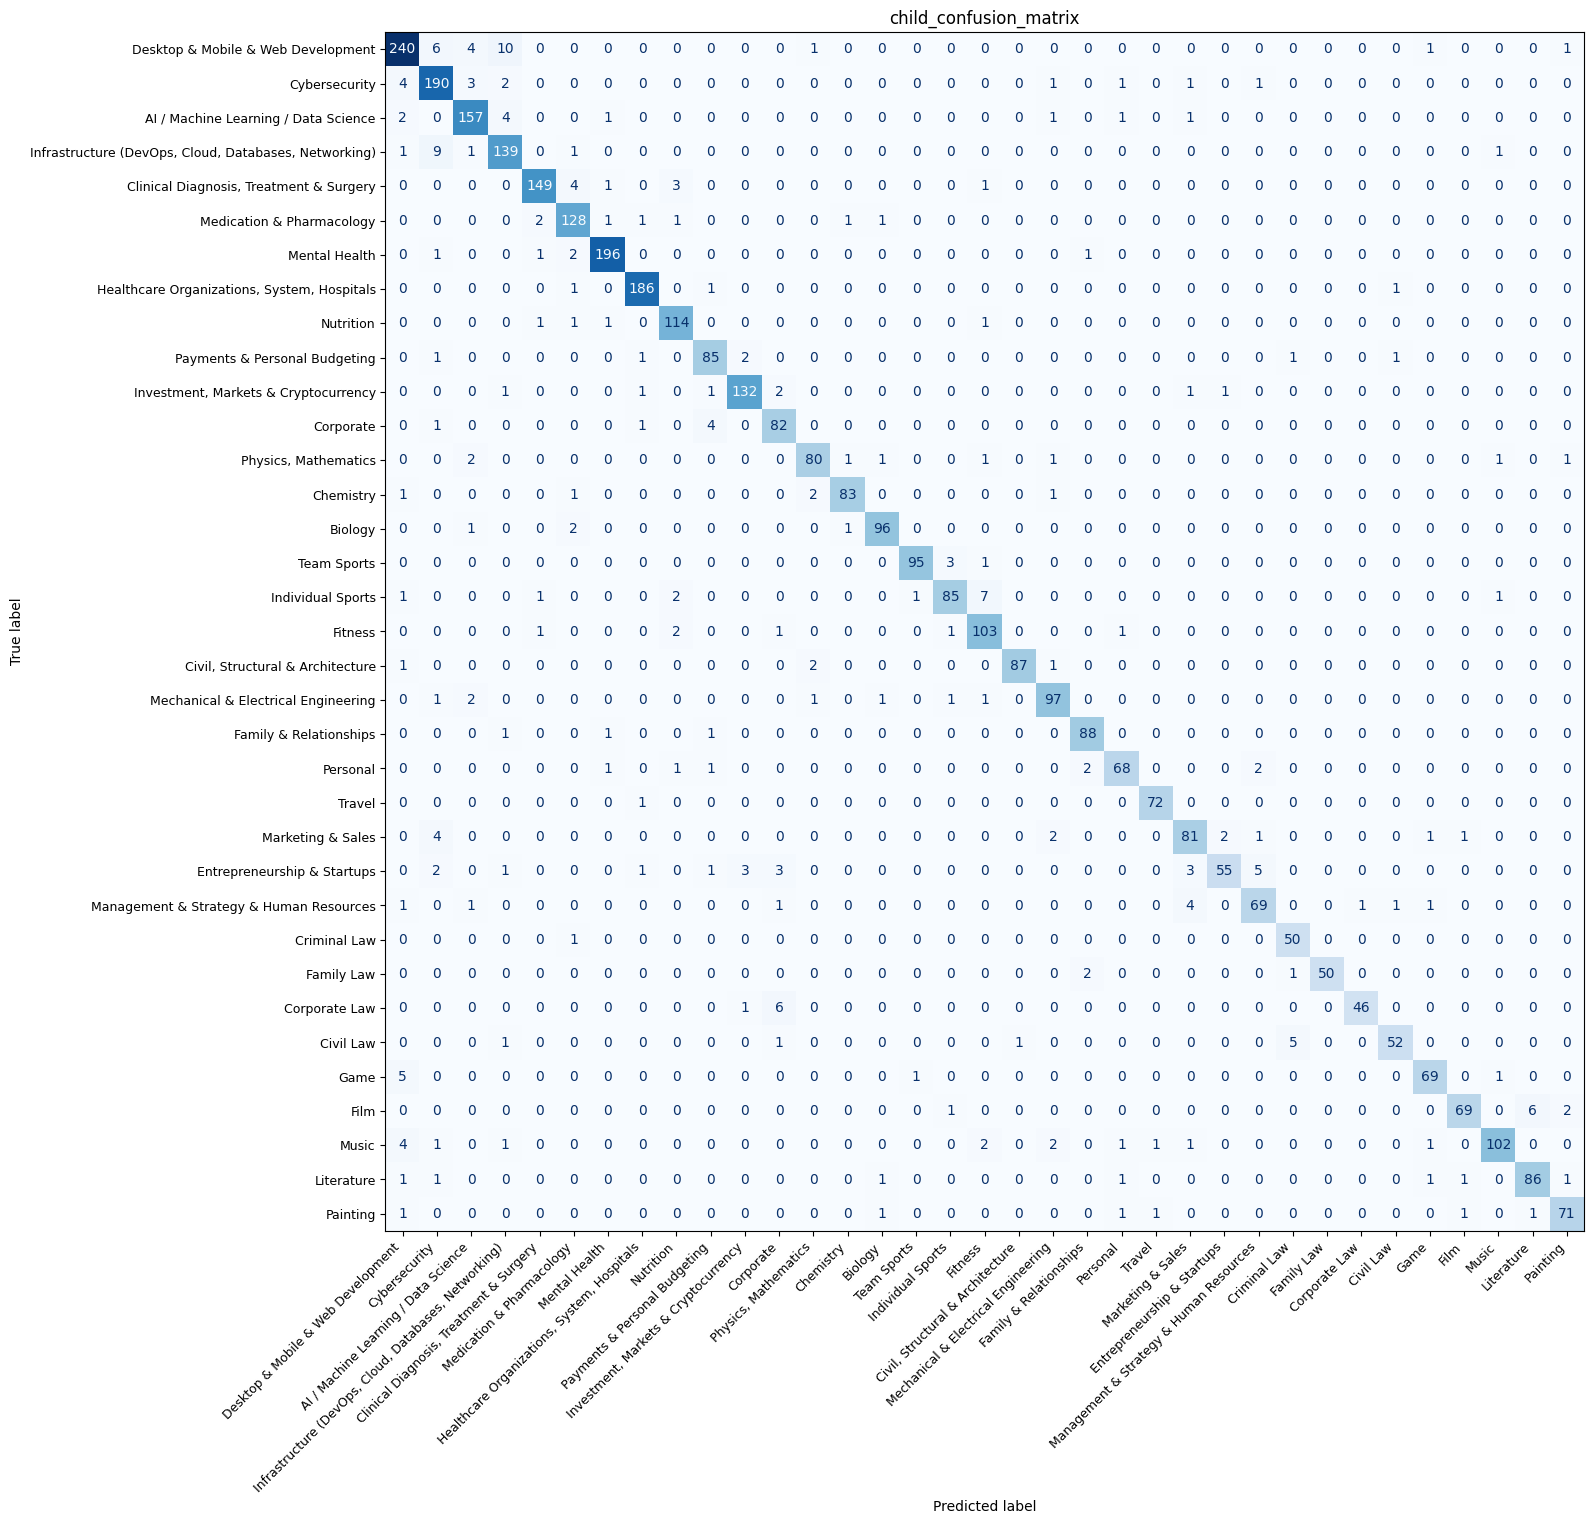

Saved to confusion_matrix.png


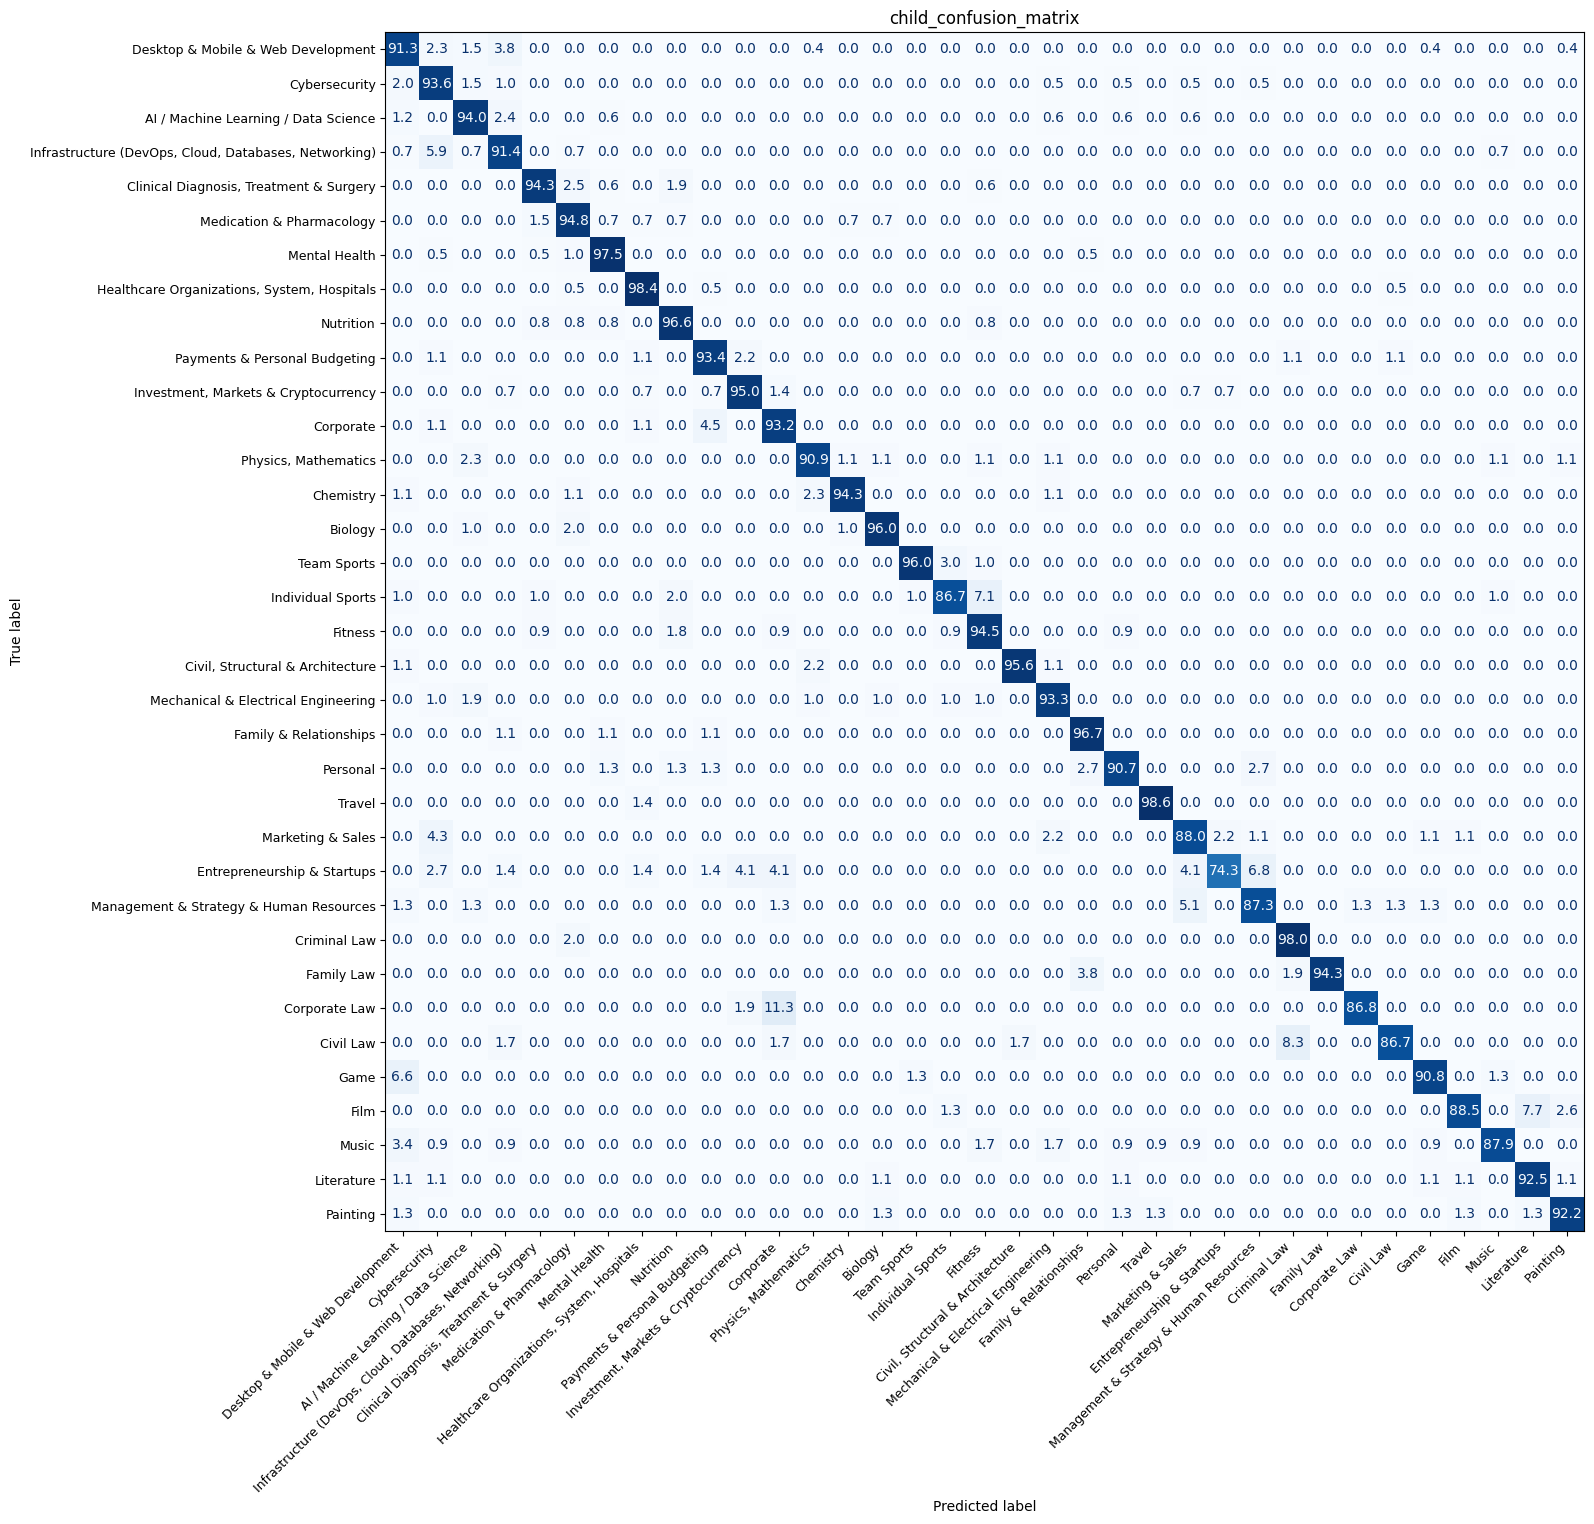

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,86.88%,89.46%,91.81%,91.25%,92.58%,94.01%,89.10%,90.98%,92.90%,785.0
1,Medical,90.78%,94.70%,97.03%,94.30%,96.33%,98.41%,92.75%,95.50%,97.64%,801.0
2,Finance,85.42%,90.50%,95.65%,93.18%,93.85%,94.96%,89.13%,92.11%,95.31%,318.0
3,Science,93.02%,94.86%,96.51%,90.91%,93.74%,96.00%,91.95%,94.29%,95.52%,276.0
4,Sports,88.03%,93.13%,97.94%,86.73%,92.40%,95.96%,89.95%,92.68%,96.94%,306.0
5,Engineering,91.51%,95.19%,98.86%,93.27%,94.44%,95.60%,92.38%,94.79%,97.21%,195.0
6,Personal,91.89%,94.60%,97.30%,90.67%,95.33%,98.63%,91.28%,94.96%,97.96%,239.0
7,Business,88.04%,90.44%,94.83%,74.32%,83.24%,88.04%,83.33%,86.42%,88.04%,245.0
8,Law,87.72%,95.03%,100.00%,86.67%,91.46%,98.04%,90.43%,93.03%,97.09%,217.0
9,Art,92.47%,94.24%,96.23%,87.93%,90.37%,92.47%,91.89%,92.24%,92.81%,440.0


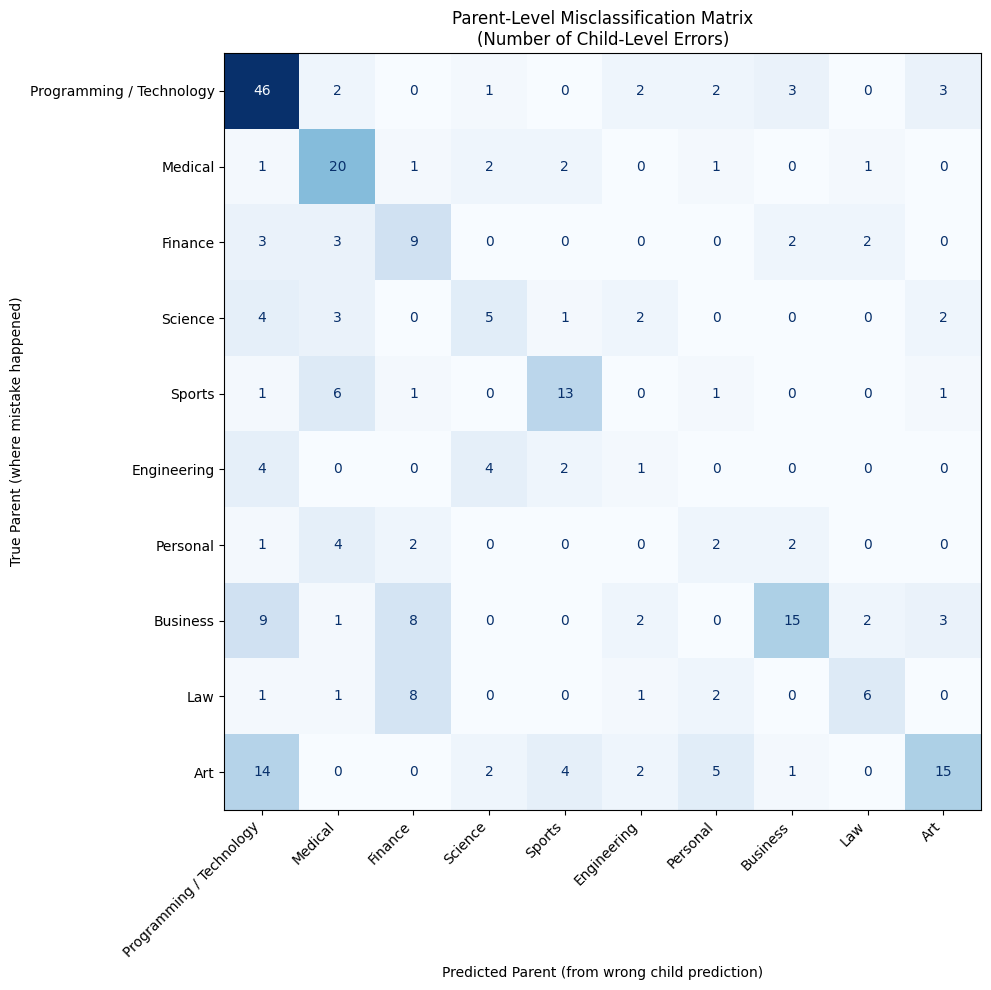

In [ ]:
y_pred = evaluate_model(
    classifier,
    X_test,
    y_test,
    LABEL_ORDER,
    id_to_label,
    HIERARCHY,
)

### Convert Test Dataset to Pandas DataFrame

In [ ]:
import json
import pandas as pd


def save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
):
    # Make a copy so we don't modify the original
    df_test = df_test.copy()

    # Add predictions
    df_test["predicted_label"] = y_pred

    # Keep only misclassified samples
    misclassified = df_test[
        df_test["label"] != df_test["predicted_label"]
    ].copy()

    # Save ALL columns
    misclassified.to_json(
        output_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(f"Misclassified samples: {len(misclassified)}")
    print(f"Saved to: {output_path}")

    return misclassified

In [ ]:
df_test = test_ds.to_pandas()

### Save Misclassified Samples

In [ ]:
save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
)

Misclassified samples: 5565
Saved to: misclassified_samples.json


,text,old_label,old_parent_label,generator_model,source,generation_group,label,parent_label,use_for_train,label_id,predicted_label
0,What is the practical difference between reali...,None,None,GPT-5.6 Luna,generated,second_label_desc_single,"Investment, Markets & Cryptocurrency",Finance,True,10,10
1,My childhood friend group of six people has be...,None,None,MiMo V2.5 Free,generated,second_label_desc_single_2,Family & Relationships,Personal,True,20,20
2,How can I have natuarally bi breasts? Are ther...,None,None,None,None,None,Nutrition,Medical,None,8,8
3,"Can you give me a list of 5 words, each contai...",None,None,None,None,None,Literature,Art,None,33,33
4,My psychiatrist is evaluating me for schizoaff...,None,None,GPT-5.6 Luna,generated,second_label_desc_parent,Mental Health,Medical,True,6,6
...,...,...,...,...,...,...,...,...,...,...,...
5560,Our regional network has long waits for new-pa...,None,None,GPT-5.6 Luna,generated,second_label_desc_single,"Healthcare Organizations, System, Hospitals",Medical,True,7,7
5561,Could you build a five-day lunch rotation that...,None,None,GPT-5.6 Luna,generated,second_label_desc_single,Nutrition,Medical,True,8,8
5562,How to debounce search input?,Desktop & Mobile & Web Development,Technology & Programming,deepseek-v4,generated,Technology_parent,Desktop & Mobile & Web Development,Programming / Technology,True,0,0
5563,How does camouflage evolve?,None,None,GPT-5.6 Luna,generated,second_label_desc_single,Biology,Science,True,14,14


### Analyze Misclassification by Generation Group

In [ ]:
import json
import pandas as pd

# Load the JSON
with open("misclassified_samples.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Make sure the IDs are numeric
df["label_id"] = pd.to_numeric(df["label_id"])
df["predicted_label"] = pd.to_numeric(df["predicted_label"])

# Identify misclassified samples
df["misclassified"] = df["label_id"] != df["predicted_label"]

# Total samples in each generation group
total_counts = (
    df["generation_group"]
    .value_counts()
    .rename("total_samples")
)

# Misclassified samples in each generation group
misclassified_counts = (
    df.loc[df["misclassified"], "generation_group"]
    .value_counts()
    .rename("misclassified")
)

# Combine
stats = pd.concat(
    [total_counts, misclassified_counts],
    axis=1
).fillna(0)

stats["misclassified"] = stats["misclassified"].astype(int)

# Misclassification rate within each generation group
stats["misclassification_percentage"] = (
    stats["misclassified"]
    / stats["total_samples"]
    * 100
).round(2)

# Sort by generation group
stats = stats.sort_index()

print(stats.to_string())

                                               total_samples  misclassified  misclassification_percentage
generation_group                                                                                         
10_labels_1                                               20              3                         15.00
10_labels_2                                               22              2                          9.09
10_labels_2_no_short_text                                 23              2                          8.70
10_labels_2_shuffled                                      10              2                         20.00
10_labels_2_shuffled_full                                 19              3                         15.79
10_labels_3                                               20              2                         10.00
10_labels_3_shuffled                                      19              0                          0.00
36_labels_1                                   

### Run Word Overlap Analysis for Single Classifier

In [ ]:
results = run_word_overlap_analysis(
    X_train=X_train_raw,
    y_train=y_train_raw,
    X_test=X_test_raw,
    y_test=y_test_raw,
    y_pred=y_pred,
    label_order=LABEL_ORDER,
    hierarchy=HIERARCHY,
    top_n=10,
)

### Generate Classification Report for Single Classifier

### eval

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
# Predictions
y_pred = classifier.predict(X_test)

# Report results using human-readable class names
target_names = [id_to_label[i] for i in range(len(id_to_label))]

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=target_names))
summary_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1-Score', 'Weighted F1-Score'],
    'Test': [
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average='macro'),
        f1_score(y_test, y_pred, average='weighted')
    ]
})
summary_metrics['Test'] = summary_metrics['Test'].map('{:.2%}'.format)
display(summary_metrics)

### Plot Confusion Matrix for Single Classifier

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

num_classes = len(target_names)

# Moderate dynamic size
fig_size = min(max(8, num_classes * 0.8), 16)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

# Manually set tick positions and labels
ax.set_xticks(range(len(LABEL_ORDER)))
ax.set_xticklabels(LABEL_ORDER, rotation=45, ha="right", fontsize=9)

ax.set_yticks(range(len(LABEL_ORDER)))
ax.set_yticklabels(LABEL_ORDER, fontsize=9)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()

# Save with reasonable resolution
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)  # Important: frees memory

print("Confusion matrix saved successfully.")

### Define Child-to-Parent Mapping

In [ ]:
child_to_parent = {
    child: parent
    for parent, children in HIERARCHY.items()
    for child in children
}

### Generate Classification Report (Hierarchical Model)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    labels=list(range(len(LABEL_ORDER))),
    target_names=LABEL_ORDER,
    output_dict=True,
    zero_division=0
)

### Generate Parent Summary (Hierarchical Model)

In [ ]:
import pandas as pd

rows = []

for parent, children in HIERARCHY.items():

    metrics = {
        "precision": [],
        "recall": [],
        "f1-score": [],
        "support": []
    }

    for child in children:
        cls = report[child]

        metrics["precision"].append(cls["precision"])
        metrics["recall"].append(cls["recall"])
        metrics["f1-score"].append(cls["f1-score"])
        metrics["support"].append(cls["support"])

    row = {
        "Parent": parent,

        "Precision Min": min(metrics["precision"]),
        "Precision Avg": sum(metrics["precision"]) / len(metrics["precision"]),
        "Precision Max": max(metrics["precision"]),

        "Recall Min": min(metrics["recall"]),
        "Recall Avg": sum(metrics["recall"]) / len(metrics["recall"]),
        "Recall Max": max(metrics["recall"]),

        "F1 Min": min(metrics["f1-score"]),
        "F1 Avg": sum(metrics["f1-score"]) / len(metrics["f1-score"]),
        "F1 Max": max(metrics["f1-score"]),

        "Support": sum(metrics["support"])
    }

    rows.append(row)

parent_summary = pd.DataFrame(rows)

# prettier percentages
for c in parent_summary.columns:
    if c not in ["Parent", "Support"]:
        parent_summary[c] = parent_summary[c].map("{:.2%}".format)

display(parent_summary)

### Extract True and Predicted Parent Labels

In [ ]:
true_parent = [
    child_to_parent[id_to_label[y]]
    for y in y_test
]

pred_parent = [
    child_to_parent[id_to_label[y]]
    for y in y_pred
]

### Get Parent Names

In [ ]:
parent_names = list(HIERARCHY.keys())

### Create Parent Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

parent_cm = confusion_matrix(
    true_parent,
    pred_parent,
    labels=parent_names
)


### Zero Out Diagonal of Parent Confusion Matrix

In [ ]:
import numpy as np

parent_cm = parent_cm.copy()

np.fill_diagonal(parent_cm, 0)

### Plot Parent Confusion Matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=parent_cm,
    display_labels=parent_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### List Files in Current Directory

In [ ]:
import os

print(os.listdir())

### Convert Datasets to Pandas for Hierarchical Model

# Hierarchical

## Preprocess data for hierarchical

## Train Classifier (Text + parent) as input

In [ ]:
# Convert your Hugging Face train and test datasets to DataFrames
df_train = train_ds.to_pandas()
df_test = test_ds.to_pandas()

# Add the parent_label column to both DataFrames
df_train['parent_label'] = df_train['label'].map(CHILD_TO_PARENT)
df_test['parent_label'] = df_test['label'].map(CHILD_TO_PARENT)

### Create Input Text with Parent Category for Hierarchical Model

In [ ]:
df_train["input_text"] = (
    "Parent Category: "
    + df_train["parent_label"]
    + "\nText: "
    + df_train["text"]
)

df_test["input_text"] = (
    "Parent Category: "
    + df_test["parent_label"]
    + "\nText: "
    + df_test["text"]
)


### Convert to Hugging Face Dataset for Hierarchical Model

In [ ]:
train_new = Dataset.from_pandas(
    df_train[["input_text", "label_id"]]
        .rename(columns={"input_text": "text"}),
    preserve_index=False
)

test_new = Dataset.from_pandas(
    df_test[["input_text", "label_id"]]
        .rename(columns={"input_text": "text"}),
    preserve_index=False
)

### Inspect a Sample from the New Hierarchical Training Dataset

In [ ]:
print(train_new[0])
print(test_new[0])

### Extract Embeddings for Hierarchical Model

In [ ]:
# embedding extraction
train_embedded_new = train_new.map(extract_embeddings, batched=True, batch_size=32)
test_embedded_new = test_new.map(extract_embeddings, batched=True, batch_size=32)

### Convert Embeddings and Labels to NumPy Arrays for Hierarchical Model

In [ ]:
# Convert features and target labels into numpy arrays
X_train_new = np.array(train_embedded_new["embedding"])
y_train_new = np.array(train_embedded_new["label_id"])

X_test_new = np.array(test_embedded_new["embedding"])
y_test_new = np.array(test_embedded_new["label_id"])

### Train Logistic Regression Classifier for Hierarchical Model

In [ ]:
classifier = LogisticRegression(max_iter=1000, C=1.0)
classifier.fit(X_train_new, y_train_new)

### Evaluate Hierarchical Model Performance

## Evaluate

In [ ]:
y_pred_new = evaluate_model(
    classifier,
    X_test_new,
    y_test_new,
    LABEL_ORDER,
    id_to_label,
    HIERARCHY,
)

### Run Word Overlap Analysis for Hierarchical Model

In [ ]:
results = run_word_overlap_analysis(
    X_train=X_train_raw,
    y_train=y_train_raw,
    X_test=X_test_raw,
    y_test=y_test_raw,
    y_pred=y_pred_new,
    label_order=LABEL_ORDER,
    hierarchy=HIERARCHY,
    top_n=10,
)

### Generate Classification Report for Hierarchical Model

### eval

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
# Predictions
y_pred = classifier.predict(X_test_new)

# Report results using human-readable class names
target_names = [id_to_label[i] for i in range(len(id_to_label))]

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_new, y_pred) * 100:.2f}%\n")
print(classification_report(y_test_new, y_pred, target_names=target_names))
summary_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1-Score', 'Weighted F1-Score'],
    'Test': [
        accuracy_score(y_test_new, y_pred),
        f1_score(y_test_new, y_pred, average='macro'),
        f1_score(y_test_new, y_pred, average='weighted')
    ]
})
summary_metrics['Test'] = summary_metrics['Test'].map('{:.2%}'.format)
display(summary_metrics)

### Plot Confusion Matrix for Hierarchical Model

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

num_classes = len(target_names)

# Moderate dynamic size
fig_size = min(max(8, num_classes * 0.8), 16)

fig, ax = plt.subplots(figsize=(fig_size, fig_size))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

# Manually set tick positions and labels
ax.set_xticks(range(len(LABEL_ORDER)))
ax.set_xticklabels(LABEL_ORDER, rotation=45, ha="right", fontsize=9)

ax.set_yticks(range(len(LABEL_ORDER)))
ax.set_yticklabels(LABEL_ORDER, fontsize=9)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.tight_layout()

# Save with reasonable resolution
plt.savefig(
    "confusion_matrix_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close(fig)  # Important: frees memory

print("Confusion matrix saved successfully.")

### Convert Datasets to Pandas for Dynamic Training

## Dynamic Training for all labels

In [ ]:
# Convert your Hugging Face train and test datasets to DataFrames
df_train = train_ds.to_pandas()
df_test = test_ds.to_pandas()

# Add the parent_label column to both DataFrames
df_train['parent_label'] = df_train['label'].map(CHILD_TO_PARENT)
df_test['parent_label'] = df_test['label'].map(CHILD_TO_PARENT)

### Inspect First Label in Training DataFrame

In [ ]:
df_train['label'][0]

### Inspect First Raw Label ID in Training Set

In [ ]:
y_train_raw[0]

### Train Child Classifiers per Parent Category

In [ ]:
child_classifiers = {}

for parent_name in HIERARCHY.keys():
    # Mask to select only rows belonging to the current parent
    mask = (df_train['parent_label'] == parent_name)

    X_train_sub = X_train[mask]
    y_train_sub = df_train[mask]['label'].values

    # Train and store in dictionary keyed by parent name
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_sub, y_train_sub)

    child_classifiers[parent_name] = clf
    print(f"✅ Child Classifier trained for: '{parent_name}' ({len(np.unique(y_train_sub))} sub-classes)")

### Generate Oracle Predictions for Dynamic Model

## Evaluate

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, f1_score

oracle_predictions = []

for idx, row in df_test.iterrows():

    # Ground-truth parent (Oracle)
    parent = row["parent_label"]

    # Get the corresponding classifier
    clf = child_classifiers[parent]

    # Predict the child label
    pred = clf.predict(X_test[idx].reshape(1, -1))[0]

    oracle_predictions.append(pred)

# Save predictions
df_test["oracle_prediction"] = oracle_predictions

### Convert Oracle Predictions to Label IDs

### misclassification-overlap

In [ ]:
# Convert oracle string labels -> integer label IDs
label_to_id = {
    label: idx
    for idx, label in enumerate(LABEL_ORDER)
}

oracle_predictions_ids = [
    label_to_id[pred]
    for pred in oracle_predictions
]

### Run Word Overlap Analysis for Oracle Predictions

In [ ]:
results = run_word_overlap_analysis(
    X_train=X_train_raw,
    y_train=y_train_raw,
    X_test=X_test_raw,
    y_test=y_test_raw,
    y_pred=oracle_predictions_ids,
    label_order=LABEL_ORDER,
    hierarchy=HIERARCHY,
    top_n=10,
)

### Evaluate Each Parent Separately for Dynamic Model

### metrics

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import os

# Folder to save confusion matrices
os.makedirs("parent_confusion_matrices", exist_ok=True)

parent_results = {}

# Evaluate each parent separately
for parent in HIERARCHY.keys():
    # Get only samples belonging to this parent
    parent_df = df_test[df_test["parent_label"] == parent]

    y_true_parent = parent_df["label"]
    y_pred_parent = parent_df["oracle_prediction"]

    # Metrics
    accuracy = accuracy_score(y_true_parent, y_pred_parent)
    macro_f1 = f1_score(y_true_parent, y_pred_parent, average="macro")
    weighted_f1 = f1_score(y_true_parent, y_pred_parent, average="weighted")

    parent_results[parent] = {
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }

    print("\n" + "=" * 60)
    print(f"Parent: {parent}")
    print("=" * 60)

    print(f"Accuracy: {accuracy:.2%}")
    print(f"Macro F1: {macro_f1:.2%}")
    print(f"Weighted F1: {weighted_f1:.2%}\n")

    labels = HIERARCHY[parent]

    print(
        classification_report(
            y_true_parent,
            y_pred_parent,
            labels=labels,
            target_names=labels,
            zero_division=0,
        )
    )

    # ---------------- Confusion Matrix ----------------

    labels = [
        label
        for label in HIERARCHY[parent]
        if label in y_true_parent.unique() or label in y_pred_parent.unique()
    ]
    cm = confusion_matrix(
        y_true_parent,
        y_pred_parent,
        labels=labels
    )

    fig_size = max(6, len(labels) * 1.2)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    # Don't let sklearn rotate labels
    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False
    )

    # Fix tick positions and labels manually
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(
        labels,
        rotation=45,
        ha="right",
        rotation_mode="anchor",
        fontsize=9
    )

    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(
        labels,
        fontsize=9
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.title(f"Confusion Matrix - {parent}")

    # Give rotated labels enough room
    plt.subplots_adjust(bottom=0.30, left=0.30)

    # Save image
    safe_name = parent.replace("/", "_").replace(" ", "_")

    plt.savefig(
        f"parent_confusion_matrices/{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

#     # ---------------- Confusion Matrix ----------------

#     labels = sorted(y_true_parent.unique())

#     cm = confusion_matrix(
#         y_true_parent,
#         y_pred_parent,
#         labels=labels
#     )

#     fig_size = max(6, len(labels) * 1)

#     fig, ax = plt.subplots(
#         figsize=(fig_size, fig_size)
#     )

#     disp = ConfusionMatrixDisplay(
#         confusion_matrix=cm,
#         display_labels=labels
#     )

#     disp.plot(
#         cmap="Blues",
#         values_format="d",
#         xticks_rotation=45,
#         ax=ax,
#         colorbar=False
#     )

#     plt.title(f"Confusion Matrix - {parent}")

#     plt.tight_layout()

#     # Save image
#     safe_name = parent.replace("/", "_").replace(" ", "_")

#     plt.savefig(
#         f"parent_confusion_matrices/{safe_name}.png",
#         dpi=300,
#         bbox_inches="tight"
#     )

#     plt.close(fig)


# Summary table
parent_summary = pd.DataFrame(parent_results).T

# Sort by accuracy (highest first)
parent_summary = parent_summary.sort_values(
    by="Accuracy",
    ascending=False
)

# Format after sorting
parent_summary_display = parent_summary.copy()

parent_summary_display["Accuracy"] = parent_summary_display["Accuracy"].map("{:.2%}".format)
parent_summary_display["Macro F1"] = parent_summary_display["Macro F1"].map("{:.2%}".format)
parent_summary_display["Weighted F1"] = parent_summary_display["Weighted F1"].map("{:.2%}".format)

print("\nOverall Parent Evaluation Summary (Sorted by Accuracy)")
display(parent_summary_display)

### Generate Oracle Classification Report

In [ ]:
oracle_report = classification_report(
    df_test["label"],
    df_test["oracle_prediction"],
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

print(
    classification_report(
        df_test["label"],
        df_test["oracle_prediction"],
        labels=LABEL_ORDER,
        target_names=LABEL_ORDER,
        zero_division=0,
    )
)

### Plot Oracle Child Confusion Matrix (Absolute Counts)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# All child labels in your predefined order
labels = LABEL_ORDER


# Confusion matrix
cm = confusion_matrix(
    df_test["label"],
    df_test["oracle_prediction"],
    labels=labels
)


# Dynamic size
fig_size = min(max(10, len(labels) * 0.6), 25)

fig, ax = plt.subplots(
    figsize=(fig_size, fig_size)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)


# Force label positions/order
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=8
)


ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.title("child_confusion_matrix")
plt.tight_layout()

plt.savefig(
    "oracle_child_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.title("")
plt.show()
plt.close(fig)


print("Oracle child confusion matrix saved.")

### Plot Oracle Child Confusion Matrix (Percentages)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


# All child labels in your predefined order
labels = LABEL_ORDER


# Confusion matrix
cm = confusion_matrix(
    df_test["label"],
    df_test["oracle_prediction"],
    labels=labels
)


# Convert each row to percentages
row_sums = cm.sum(axis=1, keepdims=True)

cm_percent = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
) * 100


# Dynamic size
fig_size = min(max(10, len(labels) * 0.6), 25)

fig, ax = plt.subplots(
    figsize=(fig_size, fig_size)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_percent,
    display_labels=labels
)

disp.plot(
    cmap="Blues",
    values_format=".1f",
    ax=ax,
    colorbar=False
)


# Force label positions/order
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    labels,
    rotation=45,
    ha="right",
    fontsize=8
)

ax.set_yticks(range(len(labels)))
ax.set_yticklabels(
    labels,
    fontsize=8
)


ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.title("child_confusion_matrix")
plt.tight_layout()

plt.savefig(
    "oracle_child_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.title("")
plt.show()
plt.close(fig)


print("Oracle child confusion matrix saved.")

### Generate Oracle Parent Summary Metrics

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Child-level report using your fixed child label order
oracle_report = classification_report(
    df_test["label"],
    df_test["oracle_prediction"],
    labels=LABEL_ORDER,
    target_names=LABEL_ORDER,
    output_dict=True,
    zero_division=0
)


parent_metrics = []

for parent, children in HIERARCHY.items():

    precision = []
    recall = []
    f1 = []
    support = []

    for child in children:
        metrics = oracle_report[child]

        precision.append(metrics["precision"])
        recall.append(metrics["recall"])
        f1.append(metrics["f1-score"])
        support.append(metrics["support"])

    parent_metrics.append({
        "Parent": parent,

        "Precision Min": min(precision),
        "Precision Avg": np.mean(precision),
        "Precision Max": max(precision),

        "Recall Min": min(recall),
        "Recall Avg": np.mean(recall),
        "Recall Max": max(recall),

        "F1 Min": min(f1),
        "F1 Avg": np.mean(f1),
        "F1 Max": max(f1),

        "Support": sum(support)
    })


parent_summary = pd.DataFrame(parent_metrics)


# Format percentages
for col in parent_summary.columns:
    if col not in ["Parent", "Support"]:
        parent_summary[col] = parent_summary[col].map("{:.2%}".format)

display(parent_summary)

### Plot Oracle Parent Misclassification Matrix

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Child -> Parent mapping
child_to_parent = {
    child: parent
    for parent, children in HIERARCHY.items()
    for child in children
}


parent_names = list(HIERARCHY.keys())


# Initialize empty parent mistake matrix
parent_missclass_cm = pd.DataFrame(
    0,
    index=parent_names,
    columns=parent_names
)


# Go through every child-level mistake
for true_child, pred_child in zip(
    df_test["label"],
    df_test["oracle_prediction"]
):

    # Ignore correct child predictions
    if true_child == pred_child:
        continue

    true_parent = child_to_parent[true_child]
    pred_parent = child_to_parent[pred_child]

    # Add this mistake to parent-level matrix
    parent_missclass_cm.loc[true_parent, pred_parent] += 1


parent_missclass_cm = parent_missclass_cm.values


# Plot
fig, ax = plt.subplots(
    figsize=(12, 12)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=parent_missclass_cm,
    display_labels=parent_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)


ax.set_xlabel("Predicted Parent")
ax.set_ylabel("True Parent")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title("Parent-Level Misclassification Matrix")

plt.tight_layout()
plt.show()